# V18-v2 Supplementary Figure S7: IA vs AR Three Patterns

**Purpose:** Visualize the three distinct IA-AR patterns identified in Result 4.2

| Panel | Pattern | Gene | Lineage | Tissue | Key Visual |
|---|---|---|---|---|---|
| A | IT-inherited | FOXP3 | CD4+ T | Liver | NL→IT†→IA★ progressive, AR=NL |
| B | IA-emergent | TIGIT | Myeloid | Blood | NL→IT NS, IA★↑, AR=NL |
| C | AR-advantage | GNLY | CD8+ T | Blood | IT/IA unchanged, AR★↑ |

**Prerequisite:** adata loaded in memory

In [1]:
# ============================================================
# CELL 0: GPU SETUP & VERIFICATION
# ============================================================
!pip install scanpy anndata matplotlib seaborn scipy -q

import subprocess
import sys

print("=" * 70)
print("  V18 C3: GPU ENVIRONMENT SETUP")
print("=" * 70)

# GPU detection
try:
    result = subprocess.run(['nvidia-smi', '--query-gpu=name,memory.total,compute_cap',
                            '--format=csv,noheader'], capture_output=True, text=True)
    gpu_info = result.stdout.strip()
    print(f"✅ GPU detected: {gpu_info}")
except:
    print("⚠️ No GPU detected — will use CPU fallback")

# Install CuPy for GPU acceleration
try:
    import cupy as cp
    print(f"✅ CuPy {cp.__version__} ready")
    print(f"   GPU memory: {cp.cuda.Device(0).mem_info[1] / 1e9:.1f} GB total")
except ImportError:
    print("📦 Installing CuPy...")
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', 'cupy-cuda12x', '-q'])
    import cupy as cp
    print(f"✅ CuPy {cp.__version__} installed")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.1/2.1 MB 44.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 176.6/176.6 kB 18.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.1/60.1 kB 6.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 284.1/284.1 kB 31.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.2/9.2 MB 22.5 MB/s eta 0:00:00
  V18 C3: GPU ENVIRONMENT SETUP
✅ GPU detected: NVIDIA A100-SXM4-80GB, 81920 MiB, 8.0
✅ CuPy 14.0.1 ready
   GPU memory: 85.1 GB total


In [2]:
# Cell 1: Setup
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from scipy.stats import mannwhitneyu
import os, warnings
warnings.filterwarnings('ignore')

try:
    _ = adata.shape
    print(f'adata loaded: {adata.shape}')
except:
    from google.colab import drive
    drive.mount('/content/drive')
    import scanpy as sc
    DATA_PATH = '/content/drive/MyDrive/ITLAS/data/processed/GSE182159_gut2021_annotated.h5ad'
    print('Loading h5ad...')
    adata = sc.read_h5ad(DATA_PATH)
    print(f'Loaded: {adata.shape}')

RESULTS_DIR = '/content/drive/MyDrive/ITLAS/results/version18-analysis-v2'
SAVE_DIR = os.path.join(RESULTS_DIR, 'Result4-2-supplementary_26Mar13')
os.makedirs(SAVE_DIR, exist_ok=True)

obs = adata.obs.copy()

# Column detection
COL_STAGE = 'Stage' if 'Stage' in obs.columns else [c for c in obs.columns if 'stage' in c.lower()][0]
COL_LINEAGE = 'major_lineage' if 'major_lineage' in obs.columns else [c for c in obs.columns if 'lineage' in c.lower()][0]
if 'tissue' in obs.columns:
    COL_TISSUE = 'tissue'
elif 'Tissue' in obs.columns:
    COL_TISSUE = 'Tissue'
else:
    for c in ['sample', 'Sample', 'orig.ident']:
        if c in obs.columns:
            obs['tissue_derived'] = obs[c].apply(
                lambda x: 'Liver' if ('Liver' in str(x) or '_L_' in str(x) or str(x).endswith('_L'))
                else ('Blood' if ('PBMC' in str(x) or '_P_' in str(x) or str(x).endswith('_P') or 'Blood' in str(x))
                else 'Unknown'))
            COL_TISSUE = 'tissue_derived'
            break
COL_DONOR = None
for c in ['donor', 'Donor', 'patient', 'subject', 'donor_id']:
    if c in obs.columns:
        COL_DONOR = c
        break
if COL_DONOR is None:
    for c in ['sample', 'Sample', 'orig.ident']:
        if c in obs.columns:
            obs['donor_derived'] = obs[c].astype(str).str.split('_').str[1]
            COL_DONOR = 'donor_derived'
            break

print(f'Columns: Stage={COL_STAGE}, Lineage={COL_LINEAGE}, Tissue={COL_TISSUE}, Donor={COL_DONOR}')

Mounted at /content/drive
Loading h5ad...
Loaded: (243000, 24452)
Columns: Stage=Stage, Lineage=major_lineage, Tissue=tissue, Donor=donor_derived


In [3]:
# Cell 2: Pre-extract target genes
target_genes = ['FOXP3', 'TIGIT', 'GNLY']

gene_expr = {}
for gene in target_genes:
    col = adata[:, gene].X
    if hasattr(col, 'toarray'):
        col = col.toarray().flatten()
    else:
        col = np.asarray(col).flatten()
    gene_expr[gene] = col
    print(f'{gene}: extracted, non-zero={np.count_nonzero(col)}')

def get_donor_vals(gene, lineage, tissue):
    """Get donor-level mean expression per stage."""
    mask = (obs[COL_LINEAGE] == lineage) & (obs[COL_TISSUE] == tissue)
    cells = obs[mask].copy()
    cell_indices = np.where(mask.values)[0]
    cells['expr'] = gene_expr[gene][cell_indices]
    dm = cells.groupby([COL_DONOR, COL_STAGE])['expr'].mean().reset_index()
    dm.columns = ['donor', 'stage', 'expr']
    return dm

def pairwise_test(dm, group_a, group_b):
    """Mann-Whitney U between two stages."""
    va = dm[dm['stage'] == group_a]['expr'].dropna().values
    vb = dm[dm['stage'] == group_b]['expr'].dropna().values
    if len(va) < 2 or len(vb) < 2:
        return None, None
    _, p = mannwhitneyu(va, vb, alternative='two-sided')
    return float(p), float(np.mean(vb) - np.mean(va))

print('Functions defined')

FOXP3: extracted, non-zero=2961
TIGIT: extracted, non-zero=42761
GNLY: extracted, non-zero=54429
Functions defined


In [4]:
# Cell 3: Verify numbers before plotting

panels = [
    ('FOXP3', 'CD4_T', 'Liver', 'IT-inherited'),
    ('TIGIT', 'Myeloid', 'Blood', 'IA-emergent'),
    ('GNLY', 'CD8_T', 'Blood', 'AR-advantage'),
]

STAGE_ORDER = ['NL', 'IT', 'IA', 'AR', 'CR']

for gene, lin, tis, pattern in panels:
    dm = get_donor_vals(gene, lin, tis)
    print(f'\n=== {gene} {lin} {tis} ({pattern}) ===')
    for stage in STAGE_ORDER:
        vals = dm[dm['stage'] == stage]['expr'].dropna().values
        if len(vals) > 0:
            print(f'  {stage} (n={len(vals)}): mean={np.mean(vals):.4f}')

    # Key comparisons
    for ga, gb in [('NL','IT'), ('NL','IA'), ('NL','AR'), ('IA','AR')]:
        p, diff = pairwise_test(dm, ga, gb)
        if p is not None:
            sig = '*' if p < 0.05 else ('t' if p < 0.10 else '')
            print(f'  {ga}->{gb}: p={p:.4f} {sig}')


=== FOXP3 CD4_T Liver (IT-inherited) ===
  NL (n=6): mean=0.0387
  IT (n=6): mean=0.0982
  IA (n=5): mean=0.1374
  AR (n=3): mean=0.0582
  CR (n=3): mean=0.0381
  NL->IT: p=0.0931 t
  NL->IA: p=0.0043 *
  NL->AR: p=0.5476 
  IA->AR: p=0.0357 *

=== TIGIT Myeloid Blood (IA-emergent) ===
  NL (n=5): mean=0.0000
  IT (n=5): mean=0.0017
  IA (n=4): mean=0.0079
  AR (n=3): mean=0.0001
  CR (n=3): mean=0.0042
  NL->IT: p=0.1797 
  NL->IA: p=0.0108 *
  NL->AR: p=0.3017 
  IA->AR: p=0.0497 *

=== GNLY CD8_T Blood (AR-advantage) ===
  NL (n=5): mean=0.5956
  IT (n=5): mean=0.6529
  IA (n=4): mean=0.3716
  AR (n=3): mean=1.5234
  CR (n=3): mean=0.5114
  NL->IT: p=0.6905 
  NL->IA: p=0.5556 
  NL->AR: p=0.0357 *
  IA->AR: p=0.0571 t


Saved: /content/drive/MyDrive/ITLAS/results/version18-analysis-v2/Result4-2-supplementary_26Mar13/FigS7_IA_vs_AR_Three_Patterns.png
Saved: /content/drive/MyDrive/ITLAS/results/version18-analysis-v2/FigS7_IA_vs_AR_Three_Patterns.png


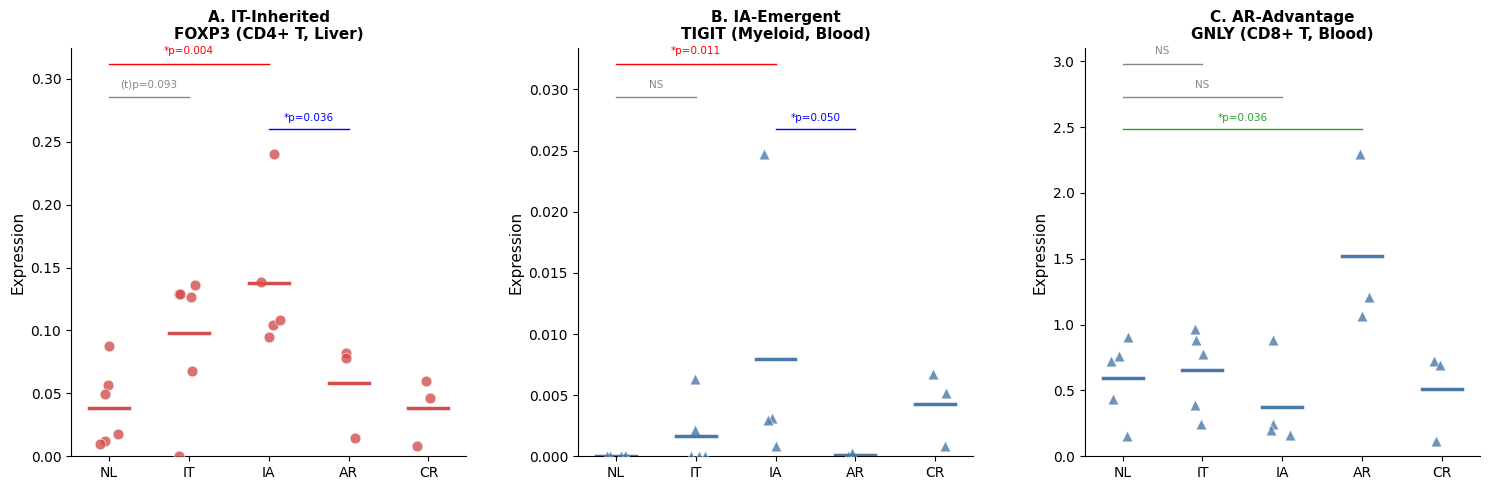

In [5]:
# Cell 4: Generate Figure S7 — Three Panels

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

STAGE_ORDER = ['NL', 'IT', 'IA', 'AR', 'CR']

panels = [
    # (gene, lineage, tissue, tissue_label, pattern_label, annotations)
    # annotations: list of (stage_a_idx, stage_b_idx, p_text, color, y_frac)
    ('FOXP3', 'CD4_T', 'Liver', 'Liver',
     'A. IT-Inherited\nFOXP3 (CD4+ T, Liver)',
     [
         (0, 1, '(t)p=0.093', '#888888', 0.88),   # NL→IT trend
         (0, 2, '*p=0.004', 'red', 0.96),           # NL→IA sig
         (2, 3, '*p=0.036', 'blue', 0.80),          # IA vs AR sig
     ]),
    ('TIGIT', 'Myeloid', 'Blood', 'Blood',
     'B. IA-Emergent\nTIGIT (Myeloid, Blood)',
     [
         (0, 1, 'NS', '#888888', 0.88),             # NL→IT NS
         (0, 2, '*p=0.011', 'red', 0.96),           # NL→IA sig
         (2, 3, '*p=0.050', 'blue', 0.80),          # IA vs AR sig
     ]),
    ('GNLY', 'CD8_T', 'Blood', 'Blood',
     'C. AR-Advantage\nGNLY (CD8+ T, Blood)',
     [
         (0, 1, 'NS', '#888888', 0.96),             # NL→IT NS
         (0, 2, 'NS', '#888888', 0.88),             # NL→IA NS
         (0, 3, '*p=0.036', '#2ca02c', 0.80),       # NL→AR sig (green for AR)
     ]),
]

for panel_idx, (gene, lineage, tissue, tis_label, title, annotations) in enumerate(panels):
    ax = axes[panel_idx]
    dm = get_donor_vals(gene, lineage, tissue)

    # Marker style: Liver = red circle, Blood = blue triangle
    if tis_label == 'Liver':
        marker, color = 'o', '#d44e4e'
    else:
        marker, color = '^', '#4878a8'

    all_vals = []
    stage_means = {}

    for i, stage in enumerate(STAGE_ORDER):
        vals = dm[dm['stage'] == stage]['expr'].dropna().values
        if len(vals) == 0:
            continue
        all_vals.extend(vals)
        stage_means[stage] = np.mean(vals)

        # Jitter
        jitter = np.random.uniform(-0.15, 0.15, len(vals))
        ax.scatter([i] * len(vals) + jitter, vals,
                  c=color, marker=marker, s=60, alpha=0.8,
                  edgecolors='white', linewidth=0.5, zorder=3)
        # Mean bar
        mean_val = np.mean(vals)
        ax.plot([i - 0.25, i + 0.25], [mean_val, mean_val],
               color=color, linewidth=2.5, zorder=4)

    # Y range for annotations
    if all_vals:
        y_max = max(all_vals) * 1.35
        ax.set_ylim(bottom=min(0, min(all_vals) * 0.95), top=y_max)
    else:
        y_max = 1.0

    # Add significance annotations
    for (idx_a, idx_b, p_text, ann_color, y_frac) in annotations:
        y_pos = y_max * y_frac
        ax.plot([idx_a, idx_b], [y_pos, y_pos],
               color=ann_color, linewidth=1.0, zorder=5)
        mid_x = (idx_a + idx_b) / 2
        ax.text(mid_x, y_pos * 1.02, p_text, ha='center', va='bottom',
               fontsize=7.5, color=ann_color)

    ax.set_xticks(range(len(STAGE_ORDER)))
    ax.set_xticklabels(STAGE_ORDER, fontsize=10)
    ax.set_ylabel('Expression', fontsize=11)
    ax.set_title(title, fontsize=11, fontweight='bold')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

plt.tight_layout(w_pad=3.0)

# Save
fig_path = os.path.join(SAVE_DIR, 'FigS7_IA_vs_AR_Three_Patterns.png')
plt.savefig(fig_path, dpi=300, bbox_inches='tight', facecolor='white')
print(f'Saved: {fig_path}')

# Also save to main results dir
fig_path2 = os.path.join(RESULTS_DIR, 'FigS7_IA_vs_AR_Three_Patterns.png')
plt.savefig(fig_path2, dpi=300, bbox_inches='tight', facecolor='white')
print(f'Saved: {fig_path2}')

plt.show()

In [6]:
# Cell 5: Print donor-level values for figure legend verification

print('=== FIGURE S7 VERIFICATION DATA ===')
print()

for gene, lin, tis, pattern in [
    ('FOXP3', 'CD4_T', 'Liver', 'IT-inherited'),
    ('TIGIT', 'Myeloid', 'Blood', 'IA-emergent'),
    ('GNLY', 'CD8_T', 'Blood', 'AR-advantage'),
]:
    dm = get_donor_vals(gene, lin, tis)
    print(f'--- Panel: {gene} {lin} {tis} ({pattern}) ---')

    for stage in STAGE_ORDER:
        vals = dm[dm['stage'] == stage]['expr'].dropna().values
        if len(vals) > 0:
            print(f'  {stage} (n={len(vals)}): mean={np.mean(vals):.4f}, '
                  f'vals={[round(float(v),4) for v in sorted(vals)]}')

    # All relevant p-values
    for ga, gb, label in [
        ('NL', 'IT', 'NL->IT'),
        ('NL', 'IA', 'NL->IA'),
        ('NL', 'AR', 'NL->AR'),
        ('IA', 'AR', 'IA vs AR'),
    ]:
        va = dm[dm['stage'] == ga]['expr'].dropna().values
        vb = dm[dm['stage'] == gb]['expr'].dropna().values
        if len(va) >= 2 and len(vb) >= 2:
            ma, mb = np.mean(va), np.mean(vb)
            _, p = mannwhitneyu(va, vb, alternative='two-sided')
            pct = (mb - ma) / ma * 100 if ma > 1e-10 else float('inf')
            sig = '*' if p < 0.05 else ('(t)' if p < 0.10 else 'NS')
            print(f'  {label}: {sig} {pct:+.1f}% p={p:.4f}')
    print()

=== FIGURE S7 VERIFICATION DATA ===

--- Panel: FOXP3 CD4_T Liver (IT-inherited) ---
  NL (n=6): mean=0.0387, vals=[0.0094, 0.0122, 0.0176, 0.0494, 0.0563, 0.0873]
  IT (n=6): mean=0.0982, vals=[0.0, 0.0678, 0.1263, 0.129, 0.1294, 0.1365]
  IA (n=5): mean=0.1374, vals=[0.0945, 0.1046, 0.1084, 0.1388, 0.2405]
  AR (n=3): mean=0.0582, vals=[0.0147, 0.078, 0.0818]
  CR (n=3): mean=0.0381, vals=[0.008, 0.0467, 0.0595]
  NL->IT: (t) +153.7% p=0.0931
  NL->IA: * +255.0% p=0.0043
  NL->AR: NS +50.4% p=0.5476
  IA vs AR: * -57.6% p=0.0357

--- Panel: TIGIT Myeloid Blood (IA-emergent) ---
  NL (n=5): mean=0.0000, vals=[0.0, 0.0, 0.0, 0.0, 0.0]
  IT (n=5): mean=0.0017, vals=[0.0, 0.0, 0.0, 0.0022, 0.0063]
  IA (n=4): mean=0.0079, vals=[0.0009, 0.003, 0.0031, 0.0247]
  AR (n=3): mean=0.0001, vals=[0.0, 0.0, 0.0003]
  CR (n=3): mean=0.0042, vals=[0.0008, 0.0052, 0.0067]
  NL->IT: NS +inf% p=0.1797
  NL->IA: * +inf% p=0.0108
  NL->AR: NS +inf% p=0.3017
  IA vs AR: * -98.7% p=0.0497

--- Panel: GNLY

In [7]:
# Cell 6: Generate figure legend

legend = """
Supplementary Figure S7. Three Distinct Patterns of IA vs AR Immune Divergence
in the Context of IT-Phase Origins.

Donor-level expression across the disease spectrum (NL, IT, IA, AR, CR) for
representative genes illustrating three patterns identified in the IA vs AR
comparison (Supplementary Table S4A).

(A) IT-inherited pattern: FOXP3 in liver CD4+ T cells. FOXP3 trended upward
in IT (NL->IT (t)p=0.093), reached significance in IA (NL->IA *p=0.004),
while AR remained at NL levels, yielding a significant IA-AR difference
(*p=0.036). This progressive accumulation across IT->IA, absent in AR,
indicates that Treg expansion is initiated during the IT phase and amplified
through IA.

(B) IA-emergent pattern: TIGIT in blood myeloid cells. TIGIT was not elevated
in IT (NL->IT NS) but emerged as significant only in IA (NL->IA *p=0.011),
with AR at NL levels (IA vs AR *p=0.050). This pattern represents newly
acquired myeloid checkpoint expression independent of IT-phase origins.

(C) AR-advantage pattern: GNLY in blood CD8+ T cells. Neither IT nor IA showed
significant GNLY changes from NL, whereas AR demonstrated marked upregulation
(NL->AR *p=0.036), indicating that effective cytotoxic function is uniquely
preserved in acute self-limited resolution.

Liver panels: red circles; Blood panels: blue triangles. Individual donor values
with group means (horizontal bars). Significance brackets: red = NL->IA,
gray = NL->IT (NS or trend), blue = IA vs AR, green = NL->AR.
Mann-Whitney U test; *p<0.05, (t)p<0.10. Panels: 3 (A-C)
"""

print(legend)

# Save legend
legend_path = os.path.join(SAVE_DIR, 'FigS7_Legend.txt')
with open(legend_path, 'w') as f:
    f.write(legend.strip())
print(f'Saved: {legend_path}')


Supplementary Figure S7. Three Distinct Patterns of IA vs AR Immune Divergence 
in the Context of IT-Phase Origins.

Donor-level expression across the disease spectrum (NL, IT, IA, AR, CR) for 
representative genes illustrating three patterns identified in the IA vs AR 
comparison (Supplementary Table S4A).

(A) IT-inherited pattern: FOXP3 in liver CD4+ T cells. FOXP3 trended upward 
in IT (NL->IT (t)p=0.093), reached significance in IA (NL->IA *p=0.004), 
while AR remained at NL levels, yielding a significant IA-AR difference 
(*p=0.036). This progressive accumulation across IT->IA, absent in AR, 
indicates that Treg expansion is initiated during the IT phase and amplified 
through IA.

(B) IA-emergent pattern: TIGIT in blood myeloid cells. TIGIT was not elevated 
in IT (NL->IT NS) but emerged as significant only in IA (NL->IA *p=0.011), 
with AR at NL levels (IA vs AR *p=0.050). This pattern represents newly 
acquired myeloid checkpoint expression independent of IT-phase origins.

(